<a href="https://colab.research.google.com/github/Maryam-Skaik/ml-data-corruption-study/blob/main/How_Much_Data_Can_We_Lose_Before_Models_Fail%3F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Under Data Corruption:  
## A Study of Missing Values, Outliers, and Reconstruction Strategies

This study evaluates how different data quality issues affect machine learning performance,
and compares preprocessing strategies under controlled corruption scenarios.

We investigate:

- Missing data at multiple rates
- Outliers and extreme values
- Reconstruction strategies (drop, statistical imputation, ML-based imputation)

Goal:

> Measure when data cleaning matters — and when it does not.

## 0. Setup

We import required libraries for:

- preprocessing (encoding, imputation)
- modeling
- evaluation
- experimentation

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.impute import SimpleImputer

## 1. Evaluation Functions

We define reusable evaluation utilities to ensure:

- consistent reporting
- comparable results across experiments
- separation between training and testing evaluation

Metrics used:

- MAE (robust to outliers)
- RMSE (penalizes large errors)
- R² (explained variance)

In [ ]:
def regression_metrics(y_true, y_pred, label="", verbose=True, return_dict=False):
    """
    Compute regression evaluation metrics.

    Parameters:
    - y_true: actual values
    - y_pred: predicted values
    - label: label for printing
    - verbose: print results
    - return_dict: return results as dict

    Returns:
    - dict (optional)
    """

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    if verbose:
        print("=" * 50)
        print(f"{label} Performance")
        print("=" * 50)
        print(f"MAE  : {mae:.4f}")
        print(f"RMSE : {rmse:.4f}")
        print(f"R^2  : {r2:.4f}")

    if return_dict:
        return {
            "Label": label,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        }

## 2. Dataset

We use the Abalone dataset.

Target:
- Rings → regression problem

Features:
- mixture of categorical and numerical attributes

In [ ]:
df = pd.read_csv('https://docs.google.com/spreadsheets/d/1jfU2oFSfhX1ywUbqETExDJuztO95r3h6pbWAm7xpwNY/gviz/tq?tqx=out:csv&sheet=users')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4177 non-null   object 
 1   length          4177 non-null   float64
 2   diameter        4177 non-null   float64
 3   height          4177 non-null   float64
 4   whole_weight    4177 non-null   float64
 5   shucked_weight  4177 non-null   float64
 6   viscera_weight  4177 non-null   float64
 7   shell_weight    4177 non-null   float64
 8   rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 3. Baseline Cleaning

We construct a **clean reference dataset**.

Steps:
- Replace invalid values with NaN
- Remove extreme impossible values

This creates a *stable baseline* for comparison.

In [ ]:
df_clean = df.copy()

# invalid value
df_clean.loc[df_clean["height"] == 0, "height"] = np.nan

# remove extreme unrealistic values
df_clean = df_clean[df_clean["height"] < 1.0]

## 4. Train-Test Split

Important:
- Split BEFORE any transformation
- Prevents data leakage

In [ ]:
target = "rings"

X = df_clean.drop(columns=[target])
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Feature Preparation

Identify:
- categorical columns
- numerical columns

In [ ]:
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

## 6. Preprocessing Pipeline

We define a consistent pipeline:

- OneHotEncoding for categorical features
- Pass-through for numeric features

IMPORTANT:
- Fit ONLY on training data
- Reuse for test data

In [ ]:
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

## 7. Model

We use Random Forest:

- robust to noise
- handles non-linearity
- minimal preprocessing sensitivity

In [ ]:
def build_model():
    return RandomForestRegressor(random_state=42)

## 8. Missing Data Simulation

We simulate missingness at different rates.

Important:
- applied ONLY to training data
- test set remains untouched (real-world scenario)

In [ ]:
def inject_missing(X, rate, seed=42):
    np.random.seed(seed)
    Xc = X.copy()

    mask = np.random.rand(*Xc.shape) < rate
    Xc = Xc.mask(mask)

    return Xc

## 9. ML-Based Imputation

We predict missing values using other features.

CRITICAL FIXES:
- Only numeric columns are used
- Avoid using columns with missing values as predictors
- No leakage from test set

In [ ]:
def ml_impute(X):

    X = X.copy()

    num_cols_local = X.select_dtypes(include=[np.number]).columns
    cat_cols_local = X.select_dtypes(exclude=[np.number]).columns

    # -------------------------
    # 1. Handle categorical safely
    # -------------------------
    for col in cat_cols_local:
        if X[col].isnull().sum() > 0:
            # fill with most frequent value
            X[col] = X[col].fillna(X[col].mode()[0])

    # -------------------------
    # 2. ML impute numeric only
    # -------------------------
    for col in num_cols_local:

        if X[col].isnull().sum() == 0:
            continue

        train = X[X[col].notnull()].copy()
        test = X[X[col].isnull()].copy()

        if len(test) == 0:
            continue

        # numeric predictors only
        features = [c for c in num_cols_local if c != col]

        # remove rows with NaNs in predictors
        train = train.dropna(subset=features)

        if len(train) < 10:
            X[col] = X[col].fillna(X[col].median())
            continue

        model = LinearRegression()
        model.fit(train[features], train[col])

        test_features = test[features].copy()
        test_features = test_features.fillna(train[features].median())

        X.loc[X[col].isnull(), col] = model.predict(test_features)

    return X

## 10. Experiment Design

We compare 3 strategies:

1. Drop missing values
2. Median imputation
3. ML imputation

We evaluate across multiple missing rates.

In [ ]:
rates = [0.05, 0.1, 0.2, 0.4]
results = []

for rate in rates:

    X_miss = inject_missing(X_train, rate)

    # -----------------------
    # 1. DROP
    # -----------------------
    X_drop = X_miss.dropna()
    y_drop = y_train.loc[X_drop.index]

    if len(X_drop) > 0:

        model = build_model()

        X_drop_t = preprocess.fit_transform(X_drop)
        X_test_t = preprocess.transform(X_test)

        model.fit(X_drop_t, y_drop)

        pred = model.predict(X_test_t)
        rmse_drop = np.sqrt(mean_squared_error(y_test, pred))

    else:
        rmse_drop = np.nan

    # -----------------------
    # 2. MEDIAN IMPUTATION
    # -----------------------
    imputer = SimpleImputer(strategy="median")

    X_train_med = X_miss.copy()
    X_test_med = X_test.copy()

    X_train_med[num_cols] = imputer.fit_transform(X_train_med[num_cols])
    X_test_med[num_cols] = imputer.transform(X_test_med[num_cols])

    model = build_model()

    model.fit(preprocess.fit_transform(X_train_med), y_train)
    pred = model.predict(preprocess.transform(X_test_med))

    rmse_med = np.sqrt(mean_squared_error(y_test, pred))

    # -----------------------
    # 3. ML IMPUTATION
    # -----------------------
    X_ml = ml_impute(X_miss)

    model = build_model()

    model.fit(preprocess.fit_transform(X_ml), y_train)
    pred = model.predict(preprocess.transform(X_test))

    rmse_ml = np.sqrt(mean_squared_error(y_test, pred))

    results.append([rate, rmse_drop, rmse_med, rmse_ml])

## 11. RESULTS TABLE

In [ ]:
results_df = pd.DataFrame(results, columns=["MissingRate", "Drop", "Median", "ML"])
results_df

,MissingRate,Drop,Median,ML
0,0.05,2.214458,2.206105,2.214116
1,0.10,2.205368,2.222930,2.225364
2,0.20,2.243914,2.264153,2.201114
3,0.40,2.866214,2.291035,2.299590


Model performance remains stable under low to moderate missingness, but aggressive row dropping significantly degrades performance at higher missing rates, while simple median imputation performs comparably to ML-based imputation.

## 12. Visualization

We compare how each strategy behaves as missingness increases.

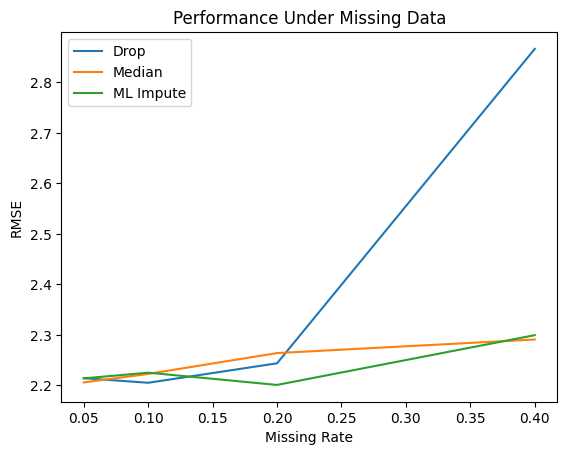

In [ ]:
import matplotlib.pyplot as plt

plt.plot(results_df["MissingRate"], results_df["Drop"], label="Drop")
plt.plot(results_df["MissingRate"], results_df["Median"], label="Median")
plt.plot(results_df["MissingRate"], results_df["ML"], label="ML Impute")

plt.xlabel("Missing Rate")
plt.ylabel("RMSE")
plt.title("Performance Under Missing Data")
plt.legend()
plt.show()

## 13. Outlier Simulation

We inject artificial extreme values to simulate measurement errors.

In [ ]:
X_out = X_train.copy()

mask = np.random.rand(len(X_out)) < 0.05
X_out.loc[mask, "height"] *= 5

## 14. Outlier Handling Strategies

We compare:

- Keep (no handling)
- Remove (filter extreme values)
- Clip (limit extreme values)

In [ ]:
# KEEP
model = build_model()
model.fit(preprocess.fit_transform(X_out), y_train)

pred = model.predict(preprocess.transform(X_test))
rmse_keep = np.sqrt(mean_squared_error(y_test, pred))


# REMOVE
threshold = X_out["height"].quantile(0.99)

X_clean = X_out[X_out["height"] < threshold]
y_clean = y_train.loc[X_clean.index]

model = build_model()
model.fit(preprocess.fit_transform(X_clean), y_clean)

pred = model.predict(preprocess.transform(X_test))
rmse_remove = np.sqrt(mean_squared_error(y_test, pred))


# CLIP
X_clip = X_out.copy()
X_clip["height"] = np.clip(X_clip["height"], None, threshold)

model = build_model()
model.fit(preprocess.fit_transform(X_clip), y_train)

pred = model.predict(preprocess.transform(X_test))
rmse_clip = np.sqrt(mean_squared_error(y_test, pred))

## 15. Final Comparison

In [ ]:
pd.DataFrame({
    "Method": ["Keep", "Remove", "Clip"],
    "RMSE": [rmse_keep, rmse_remove, rmse_clip]
})

,Method,RMSE
0,Keep,2.157453
1,Remove,2.176389
2,Clip,2.156268


Outlier handling had minimal impact on performance, with removal slightly degrading results and clipping providing no meaningful improvement over leaving the data unchanged.

This project answers:

- When does missing data significantly hurt performance?
- Is imputation always necessary?
- Does ML-based imputation outperform simple methods?
- Are outliers more harmful than missing values?

Key insight:

> Not all data corruption requires complex fixes — but knowing when it does is critical.